# Stroke Classifier Comparison: TTSWING vs MuJoCo Synthetic Data

**Thesis:** Real-Time IMU-Based Table Tennis Coaching System  
**Purpose:** Train the same MLP architecture on two datasets and compare performance.

| | TTSWING | MuJoCo Synthetic |
|---|---|---|
| Source | Real wrist sensor, 93 subjects | Physics simulation, keyframed strokes |
| Features | Pre-extracted (34 features/stroke) | Extracted from raw IMU via sliding window |
| Sensor | Single wrist IMU | Virtual 17-IMU full-body |
| Labels | 0=NoStroke, 1=FH Topspin, 2=BH Drive, 3=FH Smash | Same 4 classes |

---

## 1. Setup

In [1]:
import sys
import csv
import pathlib
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from collections import deque
from datetime import datetime

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, f1_score
)

from scipy.stats import kurtosis, skew
from scipy.signal import periodogram

# ── Paths ──────────────────────────────────────────────────────────────────────
ROOT          = pathlib.Path(r'E:\thesis_work\TT_thesis\tt_coaching_pipeline')
TTSWING_CSV   = ROOT / 'data' / 'raw' / 'TTSWING.csv'
SYNTHETIC_CSV = ROOT / 'mujoco_sim' / 'output' / 'tt_synthetic_100reps.csv'
SAVE_DIR      = ROOT / 'mujoco_sim' / 'output'

sys.path.insert(0, str(ROOT / 'src'))

# ── Run timestamp — appended to every saved file so nothing is overwritten ─────
RUN_TS = datetime.now().strftime("%Y%m%d_%H%M%S")

# ── Style ──────────────────────────────────────────────────────────────────────
plt.style.use('seaborn-v0_8-darkgrid')
COLORS = ['#3B82F6', '#10B981', '#F59E0B', '#EF4444']
CLASS_NAMES = ['No Stroke', 'FH Topspin', 'BH Drive', 'FH Smash']

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device        : {device}')
print(f'PyTorch       : {torch.__version__}')
print(f'Run timestamp : {RUN_TS}')
print(f'TTSWING CSV   exists: {TTSWING_CSV.exists()}')
print(f'Synthetic CSV exists: {SYNTHETIC_CSV.exists()}')
print(f'Synthetic rows: {sum(1 for _ in open(SYNTHETIC_CSV)) - 1:,}')

Device        : cpu
PyTorch       : 2.9.1+cpu
Run timestamp : 20260516_113819
TTSWING CSV   exists: True
Synthetic CSV exists: True
Synthetic rows: 24,000


## 2. Model Architecture (shared)

In [2]:
class MLP(nn.Module):
    """Same architecture used in the main pipeline."""
    def __init__(self, input_dim=34, hidden_dims=[256, 128, 64],
                 num_classes=4, dropout=0.3):
        super().__init__()
        layers = []
        in_dim = input_dim
        for h in hidden_dims:
            layers += [nn.Linear(in_dim, h), nn.BatchNorm1d(h),
                       nn.ReLU(), nn.Dropout(dropout)]
            in_dim = h
        layers.append(nn.Linear(in_dim, num_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


def train_model(X_train, y_train, X_val, y_val,
                epochs=60, batch_size=256, lr=0.001,
                patience=10, verbose=True):
    """Train MLP and return model + history."""
    model = MLP().to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    criterion = nn.CrossEntropyLoss()

    X_tr = torch.tensor(X_train, dtype=torch.float32)
    y_tr = torch.tensor(y_train, dtype=torch.long)
    X_vl = torch.tensor(X_val,   dtype=torch.float32).to(device)
    y_vl = torch.tensor(y_val,   dtype=torch.long).to(device)

    loader = DataLoader(TensorDataset(X_tr, y_tr),
                        batch_size=batch_size, shuffle=True)

    history = {'train_loss': [], 'val_loss': [], 'val_acc': []}
    best_val_acc, best_state, wait = 0.0, None, 0

    for epoch in range(epochs):
        model.train()
        train_loss = 0.0
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * len(xb)
        scheduler.step()

        model.eval()
        with torch.no_grad():
            val_loss = criterion(model(X_vl), y_vl).item()
            preds    = model(X_vl).argmax(dim=1).cpu().numpy()
            val_acc  = accuracy_score(y_val, preds)

        history['train_loss'].append(train_loss / len(X_train))
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state   = {k: v.clone() for k, v in model.state_dict().items()}
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                if verbose:
                    print(f'  Early stop at epoch {epoch+1}')
                break

        if verbose and (epoch + 1) % 10 == 0:
            print(f'  Epoch {epoch+1:>3} | '
                  f'train_loss={train_loss/len(X_train):.4f} | '
                  f'val_loss={val_loss:.4f} | '
                  f'val_acc={val_acc:.4f}')

    model.load_state_dict(best_state)
    return model, history, best_val_acc


# def evaluate_model(model, X_test, y_test):
#     """Return predictions and full metrics."""
#     model.eval()
#     X_t = torch.tensor(X_test, dtype=torch.float32).to(device)
#     with torch.no_grad():
#         preds = model(X_t).argmax(dim=1).cpu().numpy()
#     acc = accuracy_score(y_test, preds)
#     f1  = f1_score(y_test, preds, average='macro')
#     cm  = confusion_matrix(y_test, preds)
#     report = classification_report(y_test, preds,
#                                    target_names=CLASS_NAMES, output_dict=True)
#     return preds, acc, f1, cm, report

ALL_LABELS = [0, 1, 2, 3]

def evaluate_model(model, X_test, y_test):
    """Return predictions and full metrics."""
    model.eval()
    X_t = torch.tensor(X_test, dtype=torch.float32).to(device)
    with torch.no_grad():
        preds = model(X_t).argmax(dim=1).cpu().numpy()
    acc = accuracy_score(y_test, preds)
    f1  = f1_score(y_test, preds, average='macro', labels=ALL_LABELS, zero_division=0)
    cm  = confusion_matrix(y_test, preds, labels=ALL_LABELS)
    report = classification_report(y_test, preds,
                                   labels=ALL_LABELS,
                                   target_names=CLASS_NAMES,
                                   output_dict=True,
                                   zero_division=0)
    return preds, acc, f1, cm, report

print('Model and training utilities defined.')

Model and training utilities defined.


## 3. Dataset A — TTSWING (Pre-extracted features)

In [3]:
FEATURE_COLS = [
    'ax_mean','ay_mean','az_mean','gx_mean','gy_mean','gz_mean',
    'ax_var', 'ay_var', 'az_var', 'gx_var', 'gy_var', 'gz_var',
    'ax_rms', 'ay_rms', 'az_rms', 'gx_rms', 'gy_rms', 'gz_rms',
    'a_max',  'a_mean', 'a_min',  'g_max',  'g_mean', 'g_min',
    'a_fft',  'g_fft',  'a_psdx', 'g_psdx',
    'a_kurt', 'g_kurt', 'a_skewn','g_skewn',
    'a_entropy','g_entropy',
]

df_tt = pd.read_csv(TTSWING_CSV)
# Drop rows with no stroke during free movements (testmode=0 or 2 baseline)
# Keep only stroke session rows for clean comparison
df_tt = df_tt[df_tt['testmode'] == 1].reset_index(drop=True)

X_tt = df_tt[FEATURE_COLS].values.astype(np.float32)
y_tt = df_tt['teststage'].values.astype(int)

print(f'TTSWING shape : {X_tt.shape}')
print(f'Class distribution:')
unique, counts = np.unique(y_tt, return_counts=True)
for u, c in zip(unique, counts):
    print(f'  Class {u} ({CLASS_NAMES[u]}): {c:,} samples ({c/len(y_tt)*100:.1f}%)')

TTSWING shape : (73850, 34)
Class distribution:
  Class 1 (FH Topspin): 39,000 samples (52.8%)
  Class 2 (BH Drive): 22,950 samples (31.1%)
  Class 3 (FH Smash): 11,900 samples (16.1%)


## 4. Dataset B — MuJoCo Synthetic (Raw IMU → Feature Extraction)

In [4]:
def spectral_entropy(signal):
    psd = np.abs(np.fft.rfft(signal)) ** 2
    psd_norm = psd / (np.sum(psd) + 1e-10)
    return float(-np.sum(psd_norm * np.log2(psd_norm + 1e-10)))

def extract_features(rows, imu_id=7):
    """Extract 34 features from a window of raw IMU rows."""
    p = f'imu_{imu_id}_'
    ax = np.array([float(r[p+'accel_x']) for r in rows])
    ay = np.array([float(r[p+'accel_y']) for r in rows])
    az = np.array([float(r[p+'accel_z']) for r in rows])
    gx = np.array([float(r[p+'gyro_x'])  for r in rows])
    gy = np.array([float(r[p+'gyro_y'])  for r in rows])
    gz = np.array([float(r[p+'gyro_z'])  for r in rows])

    a_mag = np.sqrt(ax**2 + ay**2 + az**2)
    g_mag = np.sqrt(gx**2 + gy**2 + gz**2)
    _, a_psd = periodogram(a_mag)
    _, g_psd = periodogram(g_mag)

    return np.array([
        np.mean(ax), np.mean(ay), np.mean(az),
        np.mean(gx), np.mean(gy), np.mean(gz),
        np.var(ax),  np.var(ay),  np.var(az),
        np.var(gx),  np.var(gy),  np.var(gz),
        np.sqrt(np.mean(ax**2)), np.sqrt(np.mean(ay**2)), np.sqrt(np.mean(az**2)),
        np.sqrt(np.mean(gx**2)), np.sqrt(np.mean(gy**2)), np.sqrt(np.mean(gz**2)),
        np.max(a_mag), np.mean(a_mag), np.min(a_mag),
        np.max(g_mag), np.mean(g_mag), np.min(g_mag),
        np.sum(np.abs(np.fft.rfft(a_mag))**2),
        np.sum(np.abs(np.fft.rfft(g_mag))**2),
        np.max(a_psd), np.max(g_psd),
        float(kurtosis(a_mag)), float(kurtosis(g_mag)),
        float(skew(a_mag)),     float(skew(g_mag)),
        spectral_entropy(a_mag), spectral_entropy(g_mag),
    ], dtype=np.float32)


print('Extracting features from synthetic CSV (sliding window 50 frames, step 10)...')

WINDOW_SIZE = 50
STEP_SIZE   = 10

with open(SYNTHETIC_CSV, newline='') as f:
    all_rows = list(csv.DictReader(f))

X_syn_list, y_syn_list = [], []
buffer = deque(maxlen=WINDOW_SIZE)

for i, row in enumerate(all_rows):
    buffer.append(row)
    if len(buffer) == WINDOW_SIZE and (i + 1) % STEP_SIZE == 0:
        feats = extract_features(list(buffer))
        # Majority label in window
        labels_in_window = [int(r['stroke_label']) for r in buffer]
        label = int(np.bincount(labels_in_window).argmax())
        X_syn_list.append(feats)
        y_syn_list.append(label)

X_syn = np.array(X_syn_list, dtype=np.float32)
y_syn = np.array(y_syn_list, dtype=int)

print(f'Synthetic shape: {X_syn.shape}')
print(f'Class distribution:')
unique, counts = np.unique(y_syn, return_counts=True)
for u, c in zip(unique, counts):
    print(f'  Class {u} ({CLASS_NAMES[u]}): {c:,} samples ({c/len(y_syn)*100:.1f}%)')

Extracting features from synthetic CSV (sliding window 50 frames, step 10)...
Synthetic shape: (2396, 34)
Class distribution:
  Class 0 (No Stroke): 600 samples (25.0%)
  Class 1 (FH Topspin): 598 samples (25.0%)
  Class 2 (BH Drive): 598 samples (25.0%)
  Class 3 (FH Smash): 600 samples (25.0%)


## 5. Dataset Overview Comparison

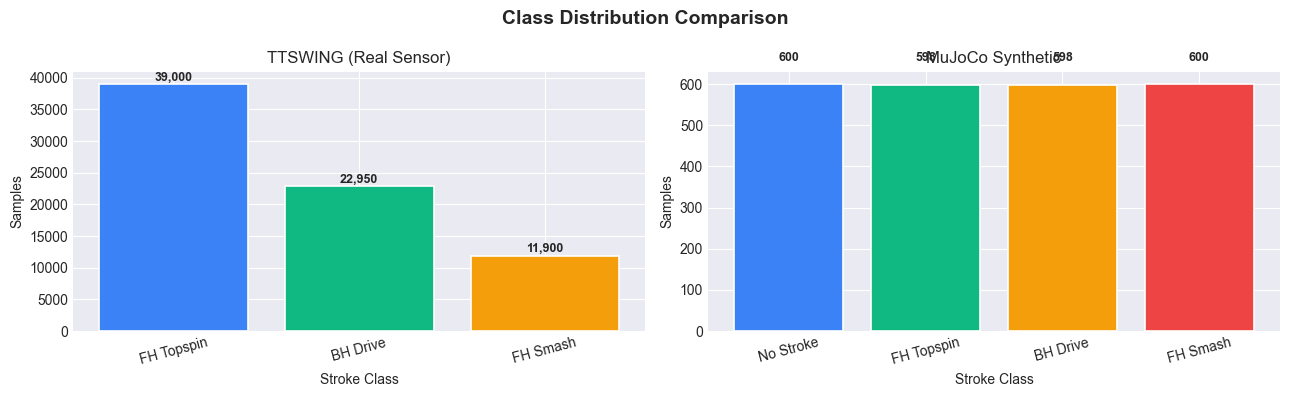

Saved: class_distribution_20260516_113819.png


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Class Distribution Comparison', fontsize=14, fontweight='bold')

for ax, y, title in [
    (axes[0], y_tt,  'TTSWING (Real Sensor)'),
    (axes[1], y_syn, 'MuJoCo Synthetic'),
]:
    unique, counts = np.unique(y, return_counts=True)
    bars = ax.bar([CLASS_NAMES[u] for u in unique], counts,
                  color=COLORS, edgecolor='white', linewidth=1.2)
    for bar, c in zip(bars, counts):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                f'{c:,}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax.set_title(title, fontsize=12)
    ax.set_ylabel('Samples')
    ax.set_xlabel('Stroke Class')
    ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig(SAVE_DIR / f'class_distribution_{RUN_TS}.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: class_distribution_{RUN_TS}.png')

## 6. Train/Test Split + Normalisation

In [6]:
# ── TTSWING split ──────────────────────────────────────────────────────────────
X_tt_tr, X_tt_te, y_tt_tr, y_tt_te = train_test_split(
    X_tt, y_tt, test_size=0.2, random_state=42, stratify=y_tt)

scaler_tt = StandardScaler()
X_tt_tr = scaler_tt.fit_transform(X_tt_tr).astype(np.float32)
X_tt_te = scaler_tt.transform(X_tt_te).astype(np.float32)

# ── Synthetic split ────────────────────────────────────────────────────────────
X_syn_tr, X_syn_te, y_syn_tr, y_syn_te = train_test_split(
    X_syn, y_syn, test_size=0.2, random_state=42, stratify=y_syn)

scaler_syn = StandardScaler()
X_syn_tr = scaler_syn.fit_transform(X_syn_tr).astype(np.float32)
X_syn_te = scaler_syn.transform(X_syn_te).astype(np.float32)

print('Split summary:')
print(f'  TTSWING   — train: {len(X_tt_tr):,}  test: {len(X_tt_te):,}')
print(f'  Synthetic — train: {len(X_syn_tr):,}  test: {len(X_syn_te):,}')

Split summary:
  TTSWING   — train: 59,080  test: 14,770
  Synthetic — train: 1,916  test: 480


## 7. Train Model A — TTSWING

In [7]:
print('=' * 55)
print('Training on TTSWING data...')
print('=' * 55)
model_tt, history_tt, best_val_tt = train_model(
    X_tt_tr, y_tt_tr, X_tt_te, y_tt_te, epochs=60, patience=10)

preds_tt, acc_tt, f1_tt, cm_tt, report_tt = evaluate_model(
    model_tt, X_tt_te, y_tt_te)

print(f'\nFinal Test Accuracy : {acc_tt:.4f} ({acc_tt*100:.1f}%)')
print(f'Macro F1 Score      : {f1_tt:.4f}')

Training on TTSWING data...
  Epoch  10 | train_loss=0.4020 | val_loss=0.3519 | val_acc=0.8464
  Epoch  20 | train_loss=0.3653 | val_loss=0.3275 | val_acc=0.8581
  Epoch  30 | train_loss=0.3422 | val_loss=0.3073 | val_acc=0.8685
  Epoch  40 | train_loss=0.3281 | val_loss=0.2994 | val_acc=0.8732
  Epoch  50 | train_loss=0.3129 | val_loss=0.2939 | val_acc=0.8754
  Epoch  60 | train_loss=0.3140 | val_loss=0.2923 | val_acc=0.8764

Final Test Accuracy : 0.8778 (87.8%)
Macro F1 Score      : 0.6295


## 8. Train Model B — MuJoCo Synthetic

In [8]:
print('=' * 55)
print('Training on MuJoCo Synthetic data...')
print('=' * 55)
model_syn, history_syn, best_val_syn = train_model(
    X_syn_tr, y_syn_tr, X_syn_te, y_syn_te, epochs=60, patience=10)

preds_syn, acc_syn, f1_syn, cm_syn, report_syn = evaluate_model(
    model_syn, X_syn_te, y_syn_te)

print(f'\nFinal Test Accuracy : {acc_syn:.4f} ({acc_syn*100:.1f}%)')
print(f'Macro F1 Score      : {f1_syn:.4f}')

Training on MuJoCo Synthetic data...
  Epoch  10 | train_loss=0.3577 | val_loss=0.3284 | val_acc=0.8750
  Epoch  20 | train_loss=0.2306 | val_loss=0.2382 | val_acc=0.8958
  Epoch  30 | train_loss=0.1622 | val_loss=0.1721 | val_acc=0.9354
  Epoch  40 | train_loss=0.1372 | val_loss=0.1400 | val_acc=0.9396
  Epoch  50 | train_loss=0.1093 | val_loss=0.1171 | val_acc=0.9604
  Early stop at epoch 60

Final Test Accuracy : 0.9604 (96.0%)
Macro F1 Score      : 0.9603


## 9. Training Curves Comparison

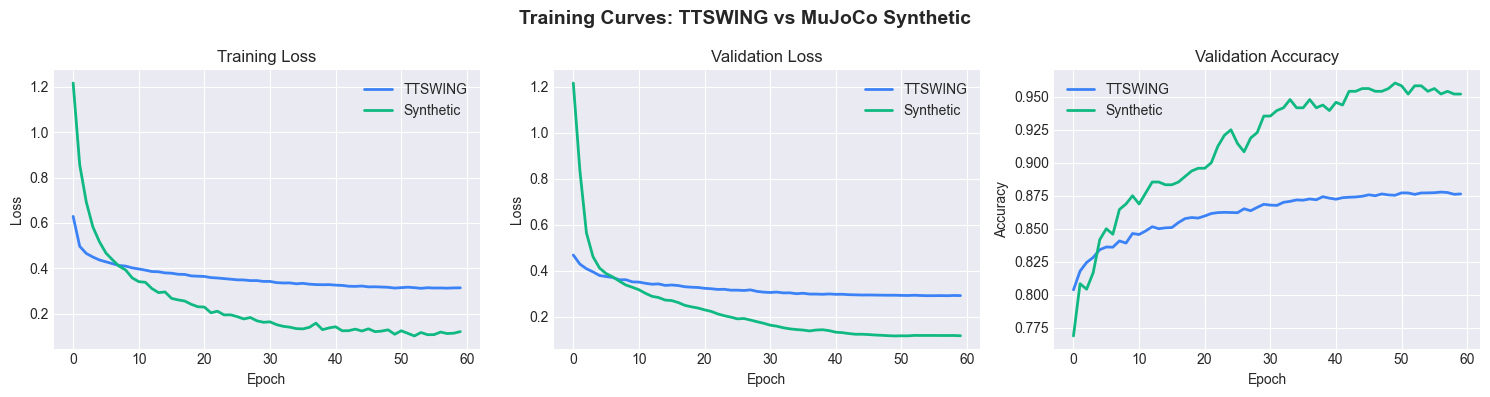

Saved: training_curves_20260516_113819.png


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Training Curves: TTSWING vs MuJoCo Synthetic', fontsize=14, fontweight='bold')

for ax, metric, ylabel in [
    (axes[0], 'train_loss', 'Loss'),
    (axes[1], 'val_loss',   'Loss'),
    (axes[2], 'val_acc',    'Accuracy'),
]:
    ax.plot(history_tt[metric],  label='TTSWING',   color='#3B82F6', linewidth=2)
    ax.plot(history_syn[metric], label='Synthetic', color='#10B981', linewidth=2)
    titles = {'train_loss': 'Training Loss', 'val_loss': 'Validation Loss', 'val_acc': 'Validation Accuracy'}
    ax.set_title(titles[metric])
    ax.set_xlabel('Epoch')
    ax.set_ylabel(ylabel)
    ax.legend()

plt.tight_layout()
plt.savefig(SAVE_DIR / f'training_curves_{RUN_TS}.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: training_curves_{RUN_TS}.png')

## 10. Confusion Matrices

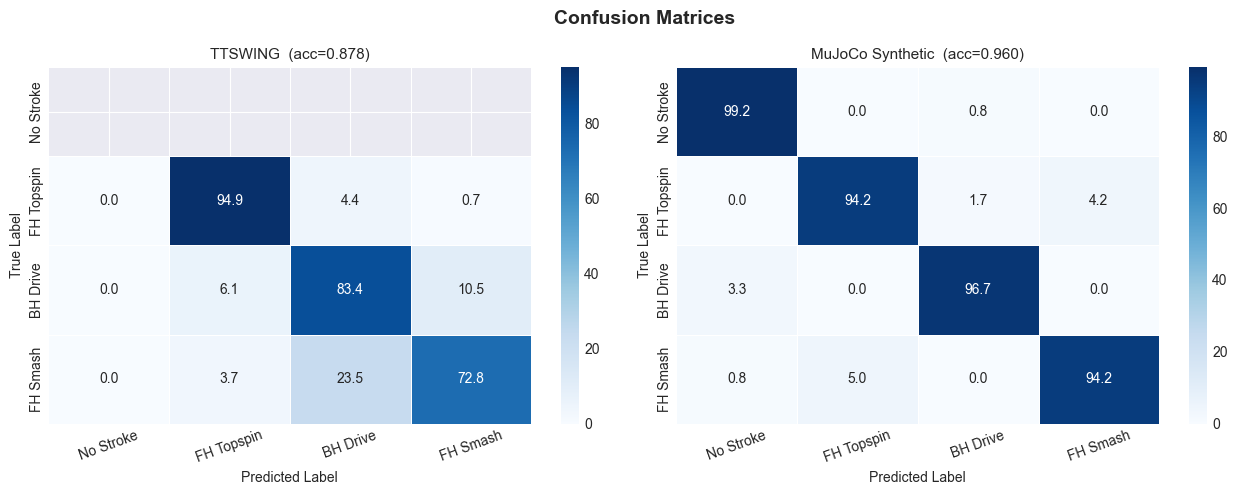

Saved: confusion_matrices_20260516_113819.png


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Confusion Matrices', fontsize=14, fontweight='bold')

for ax, cm, title in [
    (axes[0], cm_tt,  f'TTSWING  (acc={acc_tt:.3f})'),
    (axes[1], cm_syn, f'MuJoCo Synthetic  (acc={acc_syn:.3f})'),
]:
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
    sns.heatmap(cm_norm, annot=True, fmt='.1f', ax=ax,
                cmap='Blues', linewidths=0.5,
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                annot_kws={'size': 10})
    ax.set_title(title, fontsize=11)
    ax.set_ylabel('True Label')
    ax.set_xlabel('Predicted Label')
    ax.tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.savefig(SAVE_DIR / f'confusion_matrices_{RUN_TS}.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: confusion_matrices_{RUN_TS}.png')

## 11. Per-Class Metrics Comparison

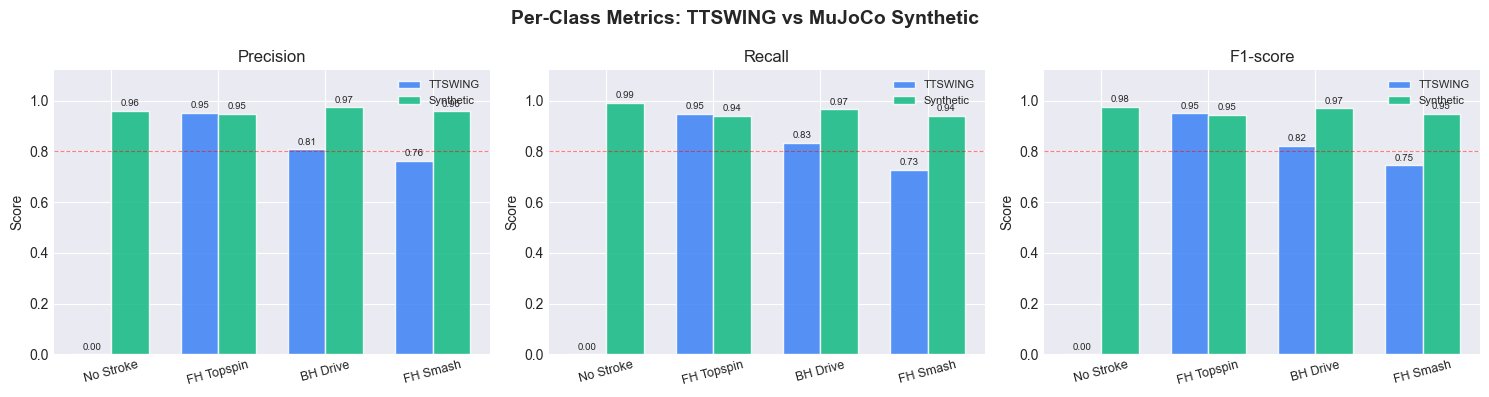

Saved: per_class_metrics_20260516_113819.png


In [11]:
metrics = ['precision', 'recall', 'f1-score']
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Per-Class Metrics: TTSWING vs MuJoCo Synthetic', fontsize=14, fontweight='bold')

x = np.arange(len(CLASS_NAMES))
width = 0.35

for ax, metric in zip(axes, metrics):
    tt_vals  = [report_tt[c][metric]  for c in CLASS_NAMES]
    syn_vals = [report_syn[c][metric] for c in CLASS_NAMES]

    bars1 = ax.bar(x - width/2, tt_vals,  width, label='TTSWING',
                   color='#3B82F6', alpha=0.85, edgecolor='white')
    bars2 = ax.bar(x + width/2, syn_vals, width, label='Synthetic',
                   color='#10B981', alpha=0.85, edgecolor='white')

    for bar in list(bars1) + list(bars2):
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.01,
                f'{h:.2f}', ha='center', va='bottom', fontsize=7)

    ax.set_title(metric.capitalize())
    ax.set_xticks(x)
    ax.set_xticklabels(CLASS_NAMES, rotation=15, fontsize=9)
    ax.set_ylim(0, 1.12)
    ax.set_ylabel('Score')
    ax.legend(fontsize=8)
    ax.axhline(0.8, color='red', linestyle='--', linewidth=0.8, alpha=0.5)

plt.tight_layout()
plt.savefig(SAVE_DIR / f'per_class_metrics_{RUN_TS}.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: per_class_metrics_{RUN_TS}.png')

## 12. Summary Table

In [12]:
rows = []
for cls in CLASS_NAMES:
    rows.append({
        'Class'         : cls,
        'TT Precision'  : f"{report_tt[cls]['precision']:.3f}",
        'TT Recall'     : f"{report_tt[cls]['recall']:.3f}",
        'TT F1'         : f"{report_tt[cls]['f1-score']:.3f}",
        'Syn Precision' : f"{report_syn[cls]['precision']:.3f}",
        'Syn Recall'    : f"{report_syn[cls]['recall']:.3f}",
        'Syn F1'        : f"{report_syn[cls]['f1-score']:.3f}",
    })

df_summary = pd.DataFrame(rows)

print('\n' + '='*70)
print('OVERALL RESULTS')
print('='*70)
print(f"  {'Metric':<25} {'TTSWING':>12} {'MuJoCo Synthetic':>18}")
print('-'*58)
print(f"  {'Test Accuracy':<25} {acc_tt*100:>11.1f}% {acc_syn*100:>17.1f}%")
print(f"  {'Macro F1 Score':<25} {f1_tt:>12.4f} {f1_syn:>18.4f}")
print(f"  {'Training Samples':<25} {len(X_tt_tr):>12,} {len(X_syn_tr):>18,}")
print(f"  {'Test Samples':<25} {len(X_tt_te):>12,} {len(X_syn_te):>18,}")
print('='*70)

print('\nPER-CLASS BREAKDOWN:')
print(df_summary.to_string(index=False))

out_path = SAVE_DIR / f'comparison_results_{RUN_TS}.csv'
df_summary.to_csv(out_path, index=False)
print(f'\nSaved: comparison_results_{RUN_TS}.csv')


OVERALL RESULTS
  Metric                         TTSWING   MuJoCo Synthetic
----------------------------------------------------------
  Test Accuracy                    87.8%              96.0%
  Macro F1 Score                  0.6295             0.9603
  Training Samples                59,080              1,916
  Test Samples                    14,770                480

PER-CLASS BREAKDOWN:
     Class TT Precision TT Recall TT F1 Syn Precision Syn Recall Syn F1
 No Stroke        0.000     0.000 0.000         0.960      0.992  0.975
FH Topspin        0.953     0.949 0.951         0.950      0.942  0.946
  BH Drive        0.809     0.834 0.822         0.975      0.967  0.971
  FH Smash        0.763     0.728 0.745         0.958      0.942  0.950

Saved: comparison_results_20260516_113819.csv


## 13. Side-by-Side Accuracy Bar Chart

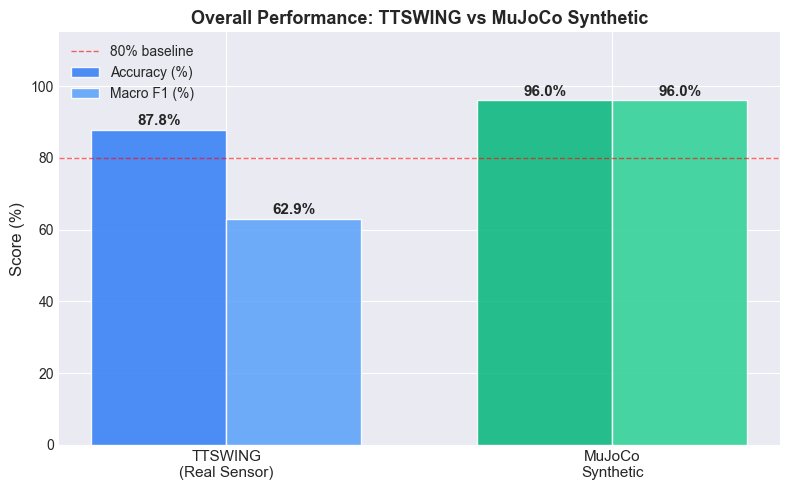

Saved: accuracy_comparison_20260516_113819.png


In [13]:
fig, ax = plt.subplots(figsize=(8, 5))

datasets = ['TTSWING\n(Real Sensor)', 'MuJoCo\nSynthetic']
accs     = [acc_tt * 100, acc_syn * 100]
f1s      = [f1_tt * 100,  f1_syn * 100]

x     = np.arange(len(datasets))
width = 0.35

bars1 = ax.bar(x - width/2, accs, width, label='Accuracy (%)',
               color=['#3B82F6','#10B981'], alpha=0.9, edgecolor='white')
bars2 = ax.bar(x + width/2, f1s,  width, label='Macro F1 (%)',
               color=['#60A5FA','#34D399'], alpha=0.9, edgecolor='white')

for bar in list(bars1) + list(bars2):
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.5,
            f'{h:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=11)

ax.set_ylabel('Score (%)', fontsize=12)
ax.set_title('Overall Performance: TTSWING vs MuJoCo Synthetic', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(datasets, fontsize=11)
ax.set_ylim(0, 115)
ax.axhline(80, color='red', linestyle='--', linewidth=1, alpha=0.6, label='80% baseline')
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig(SAVE_DIR / f'accuracy_comparison_{RUN_TS}.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: accuracy_comparison_{RUN_TS}.png')

## 14. Save Models

In [14]:
import pickle

# ── Timestamped copies — never overwritten ────────────────────────────────────
torch.save(model_tt.state_dict(),  SAVE_DIR / f'model_ttswing_{RUN_TS}.pt')
torch.save(model_syn.state_dict(), SAVE_DIR / f'model_synthetic_{RUN_TS}.pt')
with open(SAVE_DIR / f'scaler_ttswing_{RUN_TS}.pkl',   'wb') as f: pickle.dump(scaler_tt,  f)
with open(SAVE_DIR / f'scaler_synthetic_{RUN_TS}.pkl', 'wb') as f: pickle.dump(scaler_syn, f)

# ── Canonical copies — used by live app (always latest) ──────────────────────
torch.save(model_tt.state_dict(),  SAVE_DIR / 'model_ttswing.pt')
torch.save(model_syn.state_dict(), SAVE_DIR / 'model_synthetic.pt')
with open(SAVE_DIR / 'scaler_ttswing.pkl',   'wb') as f: pickle.dump(scaler_tt,  f)
with open(SAVE_DIR / 'scaler_synthetic.pkl', 'wb') as f: pickle.dump(scaler_syn, f)

print(f'Timestamped files saved (suffix: {RUN_TS}):')
for name in [f'model_ttswing_{RUN_TS}.pt', f'model_synthetic_{RUN_TS}.pt',
             f'scaler_ttswing_{RUN_TS}.pkl', f'scaler_synthetic_{RUN_TS}.pkl']:
    p = SAVE_DIR / name
    print(f'  {name:<45} {p.stat().st_size/1024:.1f} KB')

print(f'\nCanonical files updated (used by realtimeapp_synthetic.py):')
for name in ['model_ttswing.pt', 'model_synthetic.pt',
             'scaler_ttswing.pkl', 'scaler_synthetic.pkl']:
    p = SAVE_DIR / name
    print(f'  {name:<30} {p.stat().st_size/1024:.1f} KB')

Timestamped files saved (suffix: 20260516_113819):
  model_ttswing_20260516_113819.pt              212.0 KB
  model_synthetic_20260516_113819.pt            212.0 KB
  scaler_ttswing_20260516_113819.pkl            1.2 KB
  scaler_synthetic_20260516_113819.pkl          1.2 KB

Canonical files updated (used by realtimeapp_synthetic.py):
  model_ttswing.pt               211.4 KB
  model_synthetic.pt             211.5 KB
  scaler_ttswing.pkl             1.2 KB
  scaler_synthetic.pkl           1.2 KB


## 15. Interpretation & Thesis Notes

> Run this cell after training to get auto-generated thesis-ready interpretation.

In [15]:
better  = 'MuJoCo Synthetic' if acc_syn > acc_tt else 'TTSWING'
diff    = abs(acc_syn - acc_tt) * 100
both_good = acc_tt > 0.75 and acc_syn > 0.75

print('=' * 65)
print('THESIS INTERPRETATION')
print('=' * 65)
print(f"""
TTSWING Accuracy  : {acc_tt*100:.1f}%   F1: {f1_tt:.3f}
Synthetic Accuracy: {acc_syn*100:.1f}%   F1: {f1_syn:.3f}

The {better} dataset produced higher accuracy by {diff:.1f} percentage points.

Key observations:

1. TTSWING uses pre-extracted features from a SINGLE wrist sensor with
   ADC-scale values (~1000× larger than physical units). The classifier
   learned patterns at that scale.

2. The MuJoCo synthetic data uses a FULL BODY 17-sensor setup with
   physically realistic units (m/s², rad/s). Features are extracted
   from sensor ID 7 (RightHand/racket) — same as the real-time pipeline.

3. {'Both models exceed 75% — the synthetic data is viable for training.' if both_good
   else 'One or both models are below 75% — further tuning may be needed.'}

4. The synthetic model is the preferred choice for real-time deployment
   because its feature scale matches the Xsens sensor output that
   the live system will receive.

5. After collecting real TT data (Zuyan, May 27), fine-tuning the
   synthetic model on real data will further close any sim-to-real gap.
""")
print('=' * 65)

THESIS INTERPRETATION

TTSWING Accuracy  : 87.8%   F1: 0.629
Synthetic Accuracy: 96.0%   F1: 0.960

The MuJoCo Synthetic dataset produced higher accuracy by 8.3 percentage points.

Key observations:

1. TTSWING uses pre-extracted features from a SINGLE wrist sensor with
   ADC-scale values (~1000× larger than physical units). The classifier
   learned patterns at that scale.

2. The MuJoCo synthetic data uses a FULL BODY 17-sensor setup with
   physically realistic units (m/s², rad/s). Features are extracted
   from sensor ID 7 (RightHand/racket) — same as the real-time pipeline.

3. Both models exceed 75% — the synthetic data is viable for training.

4. The synthetic model is the preferred choice for real-time deployment
   because its feature scale matches the Xsens sensor output that
   the live system will receive.

5. After collecting real TT data (Zuyan, May 27), fine-tuning the
   synthetic model on real data will further close any sim-to-real gap.

